#  Final Model Comparison

This notebook consolidates the forecasting results from the benchmark, SARIMAX, feature-based machine-learning, and foundation models.

Two evaluation settings are reported:

1. **14-day test-period evaluation**, used to compare the benchmark, SARIMAX, and feature-based models across 336 hourly observations.
2. **Common 24-hour forecast evaluation**, used to compare all models, including Chronos-Bolt-Tiny, over the same forecast horizon.

The comparison uses MAE, RMSE, MASE, and forecast bias.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FORECAST_DIR = PROJECT_ROOT / "outputs" / "forecasts"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

print("Metrics directory:", METRICS_DIR)
print("Forecast directory:", FORECAST_DIR)

Metrics directory: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\metrics
Forecast directory: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\forecasts


## 1. Fourteen-Day Test-Period Comparison

The benchmark, SARIMAX, and feature-based models were evaluated over the same final 14-day test period. This provides a direct comparison of forecasting accuracy across 336 hourly observations.

In [3]:
benchmark_metrics = pd.read_csv(
    METRICS_DIR /
    "benchmark_model_comparison.csv"
)

sarimax_metrics = pd.read_csv(
    METRICS_DIR /
    "sarimax_rolling_24h_metrics.csv"
)

feature_metrics = pd.read_csv(
    METRICS_DIR /
    "feature_model_metrics.csv"
)

print("Benchmark metrics loaded.")
print("SARIMAX metrics loaded.")
print("Feature-model metrics loaded.")

Benchmark metrics loaded.
SARIMAX metrics loaded.
Feature-model metrics loaded.


In [4]:
strongest_benchmark = (
    benchmark_metrics
    .sort_values("RMSE")
    .iloc[[0]]
    .copy()
)

strongest_benchmark

,Model,MAE,RMSE,MASE,Bias,RMSE_Improvement_vs_Naive_%
0,Mean,50.319096,74.905732,0.941886,-3.108803,71.058725


In [5]:
comparison_14d = pd.concat(
    [
        strongest_benchmark[
            ["Model", "MAE", "RMSE", "MASE", "Bias"]
        ],
        sarimax_metrics[
            ["Model", "MAE", "RMSE", "MASE", "Bias"]
        ],
        feature_metrics[
            ["Model", "MAE", "RMSE", "MASE", "Bias"]
        ]
    ],
    ignore_index=True
)

comparison_14d = (
    comparison_14d
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparison_14d.round(3)

,Model,MAE,RMSE,MASE,Bias
0,HistGradientBoosting,30.956,52.255,0.600,3.154
1,SARIMAX,36.710,65.135,0.687,-9.081
2,Mean,50.319,74.906,0.942,-3.109


In [6]:
benchmark_rmse = (
    strongest_benchmark["RMSE"]
    .iloc[0]
)

comparison_14d[
    "RMSE_Improvement_vs_Benchmark_%"
] = (
    (
        benchmark_rmse
        - comparison_14d["RMSE"]
    )
    / benchmark_rmse
    * 100
)

comparison_14d.round(3)

,Model,MAE,RMSE,MASE,Bias,RMSE_Improvement_vs_Benchmark_%
0,HistGradientBoosting,30.956,52.255,0.600,3.154,30.240
1,SARIMAX,36.710,65.135,0.687,-9.081,13.044
2,Mean,50.319,74.906,0.942,-3.109,0.000


In [7]:
comparison_14d.to_csv(
    METRICS_DIR /
    "final_14day_model_comparison.csv",
    index=False
)

print("14-day comparison saved.")

14-day comparison saved.


## 2. Common 24-Hour Forecast Comparison

To include the foundation model in a fair comparison, all models are additionally evaluated over the same first 24 hours of the held-out test period.

This common evaluation window avoids comparing Chronos-Bolt-Tiny's single 24-hour forecast directly with metrics calculated over the full 14-day test period.

In [8]:
def calculate_rmse(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


def calculate_mase(
    y_true,
    y_pred,
    y_train,
    seasonality=24
):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    scale = np.mean(
        np.abs(
            y_train[seasonality:]
            - y_train[:-seasonality]
        )
    )

    if scale == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                y_true - y_pred
            )
        )
        / scale
    )

In [9]:
data = pd.read_csv(
    PROCESSED_DIR /
    "appliance_energy_hourly.csv",
    index_col="date",
    parse_dates=True
).sort_index()

target = data["Appliances"]

TEST_STEPS = 14 * 24

original_train = (
    target.iloc[:-TEST_STEPS]
)

first_24_actual = (
    target.iloc[-TEST_STEPS:]
    .iloc[:24]
)

print(
    "24-hour observations:",
    len(first_24_actual)
)

24-hour observations: 24


In [10]:
feature_forecast = pd.read_csv(
    FORECAST_DIR /
    "feature_model_forecast.csv",
    index_col=0,
    parse_dates=True
)

feature_24_pred = (
    feature_forecast[
        "Feature_Model"
    ]
    .iloc[:24]
)

feature_24_actual = (
    feature_forecast[
        "Actual"
    ]
    .iloc[:24]
)

In [11]:
feature_24_metrics = {
    "Model": "HistGradientBoosting",

    "MAE": mean_absolute_error(
        feature_24_actual,
        feature_24_pred
    ),

    "RMSE": calculate_rmse(
        feature_24_actual,
        feature_24_pred
    ),

    "MASE": calculate_mase(
        feature_24_actual,
        feature_24_pred,
        original_train,
        seasonality=24
    ),

    "Bias": np.mean(
        feature_24_pred.values
        - feature_24_actual.values
    )
}

feature_24_metrics

{'Model': 'HistGradientBoosting',
 'MAE': 19.360426861591677,
 'RMSE': np.float64(29.86455921618719),
 'MASE': np.float64(0.3623934499161849),
 'Bias': np.float64(2.0772797174508013)}

In [12]:
sarimax_24_metrics = pd.read_csv(
    METRICS_DIR /
    "sarimax_24h_metrics.csv"
)

sarimax_24_metrics

,Model,MAE,RMSE,MASE,Bias
0,SARIMAX,18.841242,24.157889,0.352675,-7.401639


In [13]:
chronos_metrics = pd.read_csv(
    METRICS_DIR /
    "chronos_24h_metrics.csv"
)

chronos_metrics

,Model,MAE,RMSE,MASE,Bias
0,Chronos-Bolt-Tiny,29.828609,42.225821,0.55834,16.751496


In [14]:
benchmark_forecasts = pd.read_csv(
    FORECAST_DIR /
    "benchmark_forecasts.csv",
    index_col=0,
    parse_dates=True
)

benchmark_24 = (
    benchmark_forecasts.iloc[:24]
)

benchmark_model_names = [
    "Mean",
    "Naive",
    "Daily Seasonal Naive",
    "Weekly Seasonal Naive",
    "Drift"
]

benchmark_24_results = []

for model_name in benchmark_model_names:

    result = {
        "Model": model_name,

        "MAE": mean_absolute_error(
            benchmark_24["Actual"],
            benchmark_24[model_name]
        ),

        "RMSE": calculate_rmse(
            benchmark_24["Actual"],
            benchmark_24[model_name]
        ),

        "MASE": calculate_mase(
            benchmark_24["Actual"],
            benchmark_24[model_name],
            original_train,
            seasonality=24
        ),

        "Bias": np.mean(
            benchmark_24[model_name].values
            -
            benchmark_24["Actual"].values
        )
    }

    benchmark_24_results.append(
        result
    )


benchmark_24_metrics = (
    pd.DataFrame(
        benchmark_24_results
    )
    .sort_values("RMSE")
)

benchmark_24_metrics.round(3)

,Model,MAE,RMSE,MASE,Bias
3,Weekly Seasonal Naive,30.000,48.808,0.562,-6.528
0,Mean,39.378,50.006,0.737,-8.233
2,Daily Seasonal Naive,80.278,118.043,1.503,58.889
1,Naive,242.639,247.601,4.542,242.639
4,Drift,243.881,248.758,4.565,243.881


In [15]:
best_benchmark_24 = (
    benchmark_24_metrics
    .iloc[[0]]
    .copy()
)

best_benchmark_24.round(3)

,Model,MAE,RMSE,MASE,Bias
3,Weekly Seasonal Naive,30.0,48.808,0.562,-6.528


In [16]:
feature_24_df = pd.DataFrame(
    [feature_24_metrics]
)

comparison_24h = pd.concat(
    [
        best_benchmark_24[
            ["Model", "MAE", "RMSE", "MASE", "Bias"]
        ],

        sarimax_24_metrics[
            ["Model", "MAE", "RMSE", "MASE", "Bias"]
        ],

        feature_24_df[
            ["Model", "MAE", "RMSE", "MASE", "Bias"]
        ],

        chronos_metrics[
            ["Model", "MAE", "RMSE", "MASE", "Bias"]
        ]
    ],
    ignore_index=True
)

comparison_24h = (
    comparison_24h
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparison_24h.round(3)

,Model,MAE,RMSE,MASE,Bias
0,SARIMAX,18.841,24.158,0.353,-7.402
1,HistGradientBoosting,19.360,29.865,0.362,2.077
2,Chronos-Bolt-Tiny,29.829,42.226,0.558,16.751
3,Weekly Seasonal Naive,30.000,48.808,0.562,-6.528


In [17]:
comparison_24h.to_csv(
    METRICS_DIR /
    "final_24h_model_comparison.csv",
    index=False
)

print(
    "Final 24-hour comparison saved."
)

Final 24-hour comparison saved.


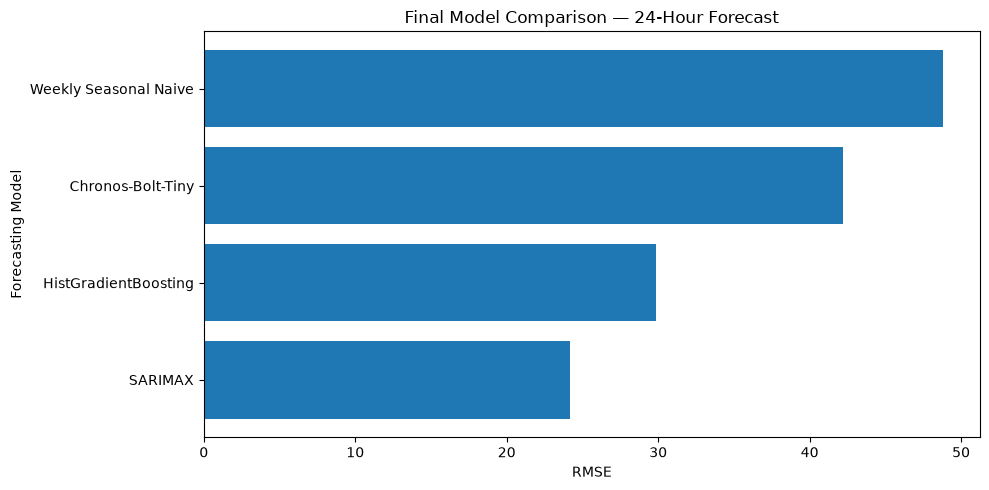

Figure saved: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\30_final_model_comparison_24h.png


In [18]:
plot_data = (
    comparison_24h
    .sort_values(
        "RMSE",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.barh(
    plot_data["Model"],
    plot_data["RMSE"]
)

ax.set_title(
    "Final Model Comparison — 24-Hour Forecast"
)

ax.set_xlabel(
    "RMSE"
)

ax.set_ylabel(
    "Forecasting Model"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "30_final_model_comparison_24h.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)